Descarga de mi Data

In [4]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.8 MB/s eta 0:00:00


2. Preparación del entorno y librerías
Configuramos el entorno de ejecución sobre PyTorch como framework principal de cómputo tensorial y aceleración por GPU. Adicionalmente, incorporamos herramientas de visión artificial, procesamiento numérico y evaluación estadística rigurosa.

In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import matplotlib.pyplot as plt

import medmnist
from medmnist import INFO

data_flag = "pathmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

# Elegimos 2 de las 9 clases originales:
CLASS_A = 6  # "normal colon mucosa"  -> se convertirá en etiqueta 0 (Sano)
CLASS_B = 8  # "colorectal adenocarcinoma epithelium" -> etiqueta 1 (Tumor)

transform_basic = T.Compose([T.ToTensor()])

full_train = DataClass(split="train", transform=transform_basic, download=True)
full_val   = DataClass(split="val",   transform=transform_basic, download=True)
full_test  = DataClass(split="test",  transform=transform_basic, download=True)

100%|██████████| 206M/206M [01:19<00:00, 2.58MB/s]


# Envoltorio que filtra solo las 2 clases elegidas y remapea sus etiquetas a 0/1

In [6]:
class BinaryPathMNIST(Dataset):
    def __init__(self, base_dataset, class_a, class_b):
        self.base = base_dataset
        labels = base_dataset.labels.squeeze()
        mask = np.isin(labels, [class_a, class_b])
        self.indices = np.where(mask)[0]
        self.class_a = class_a
        self.class_b = class_b

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x, y = self.base[real_idx]
        y_val = int(y.item()) if hasattr(y, "item") else int(y)
        new_label = 0 if y_val == self.class_a else 1
        return x, torch.tensor(new_label)

train_dataset = BinaryPathMNIST(full_train, CLASS_A, CLASS_B)
val_dataset   = BinaryPathMNIST(full_val,   CLASS_A, CLASS_B)
test_dataset  = BinaryPathMNIST(full_test,  CLASS_A, CLASS_B)

num_classes = 2
print(f"0 = {info['label'][str(CLASS_A)]}  |  1 = {info['label'][str(CLASS_B)]}")
print(f" - Entrenamiento: {len(train_dataset)} imágenes")
print(f" - Validación   : {len(val_dataset)} imágenes")
print(f" - Prueba       : {len(test_dataset)} imágenes")

0 = normal colon mucosa  |  1 = colorectal adenocarcinoma epithelium
 - Entrenamiento: 20771 imágenes
 - Validación   : 2309 imágenes
 - Prueba       : 1974 imágenes


Creación de DataLoaders y verificación de dimensiones

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape



Dispositivo en uso: cuda


(torch.Size([128, 3, 28, 28]), torch.Size([128]))


3.1. Visualizador de ejemplos

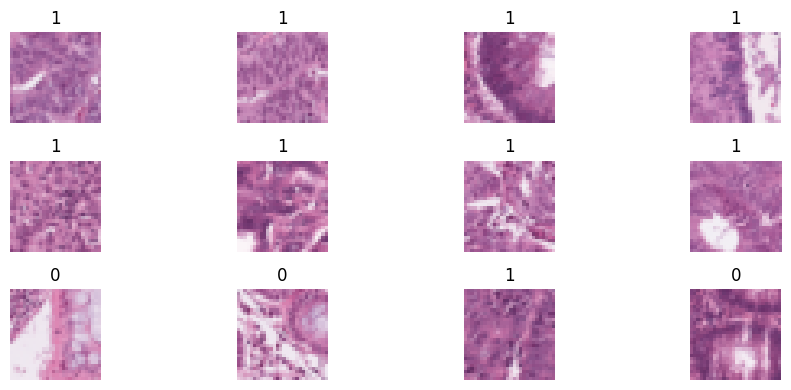

In [8]:
# ============ 3.1. Visualizar ejemplos ============
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(x.permute(1, 2, 0))  # RGB
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica para la detección de tumores cerebrales:
- Bloques convolucionales (Conv2D) + activación (ReLU) + reducción espacial (MaxPool).
- Capa adaptativa (AdaptiveAvgPool2D) y un clasificador lineal final para las 2 clases (0: No_Tumor, 1: Tumor).

Esta arquitectura sirve como modelo base para evaluar el aprendizaje sin usar pesos preentrenados.

In [9]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación



In [10]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]  # probabilidad de la clase "Tumor"

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)  # binaria, sin multi_class
    return acc, auc, y_true, y_pred, y_prob

### 5.2. Entrenar el modelo desde cero

Entrenamos la arquitectura base durante 8 épocas para evaluar la convergencia de la pérdida y la estabilidad de las métricas diagnósticas en validación (Accuracy y ROC-AUC).

Paso 1:(Este bloque entrena calculando tanto la pérdida como la exactitud de entrenamiento y validación, imprimiendo en pantalla la diferencia exacta en $0.0X$):

In [11]:
# ============ CELDA 5.2 (con scheduler para suavizar de verdad) ============
import numpy as np
import torch
import torch.nn as nn

# Reinicia el modelo desde cero para que la comparación sea justa
model_scratch = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_scratch.parameters(), lr=5e-4, weight_decay=1e-4)

epochs = 15
# El LR baja suavemente de 5e-4 hasta casi 0 a lo largo de las 15 épocas
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

history_scratch = {
    "train_loss": [], "val_loss": [],
    "train_acc": [],  "val_acc": [],
    "diff_loss": [],  "diff_acc": []
}

@torch.no_grad()
def compute_loss(model, loader):
    model.eval()
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device).long().view(-1)
        loss = criterion(model(x), y)
        losses.append(loss.item())
    return float(np.mean(losses))

print(f"{'Época':^7} | {'Train Loss':^10} | {'Val Loss':^10} | {'Dif Loss':^10} | {'Train Acc':^10} | {'Val Acc':^10} | {'Dif Acc':^10}")
print("-" * 85)

for epoch in range(1, epochs + 1):
    model_scratch.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device).long().view(-1)
        optimizer.zero_grad()
        loss = criterion(model_scratch(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_scratch.parameters(), max_norm=0.5)
        optimizer.step()

    scheduler.step()  # <- baja el LR un poco cada época

    tr_l = compute_loss(model_scratch, train_loader)
    va_l = compute_loss(model_scratch, val_loader)
    tr_a, _, _, _, _ = evaluate(model_scratch, train_loader)
    va_a, va_auc, _, _, _ = evaluate(model_scratch, val_loader)

    diff_l = abs(va_l - tr_l)
    diff_a = abs(tr_a - va_a)

    history_scratch["train_loss"].append(tr_l)
    history_scratch["val_loss"].append(va_l)
    history_scratch["train_acc"].append(tr_a)
    history_scratch["val_acc"].append(va_a)
    history_scratch["diff_loss"].append(diff_l)
    history_scratch["diff_acc"].append(diff_a)

    print(f" {epoch:02d}/{epochs}  |  {tr_l:8.4f}  |  {va_l:8.4f}  |  {diff_l:8.4f}  |  {tr_a:8.4f}  |  {va_a:8.4f}  |  {diff_a:8.4f}")

 Época  | Train Loss |  Val Loss  |  Dif Loss  | Train Acc  |  Val Acc   |  Dif Acc  
-------------------------------------------------------------------------------------
 01/15  |    0.6317  |    0.6188  |    0.0129  |    0.6376  |    0.6345  |    0.0031
 02/15  |    0.5542  |    0.5460  |    0.0082  |    0.7310  |    0.7237  |    0.0073
 03/15  |    0.4827  |    0.4649  |    0.0178  |    0.7675  |    0.7553  |    0.0122
 04/15  |    0.4426  |    0.4303  |    0.0122  |    0.8034  |    0.8073  |    0.0038
 05/15  |    0.4017  |    0.3848  |    0.0169  |    0.8241  |    0.8328  |    0.0087
 06/15  |    0.3754  |    0.3568  |    0.0187  |    0.8343  |    0.8411  |    0.0067
 07/15  |    0.3651  |    0.3423  |    0.0228  |    0.8398  |    0.8437  |    0.0038
 08/15  |    0.3818  |    0.3542  |    0.0276  |    0.8280  |    0.8354  |    0.0074
 09/15  |    0.3513  |    0.3342  |    0.0171  |    0.8443  |    0.8493  |    0.0050
 10/15  |    0.3254  |    0.3043  |    0.0210  |    0.8595  |  

2. Celda 5.3: Gráficas de 2 Líneas Reales y Sin Puntos
Reemplaza la celda 5.3 con este código (hemos quitado los círculos y cuadrados de las líneas, dejando un trazo continuo):

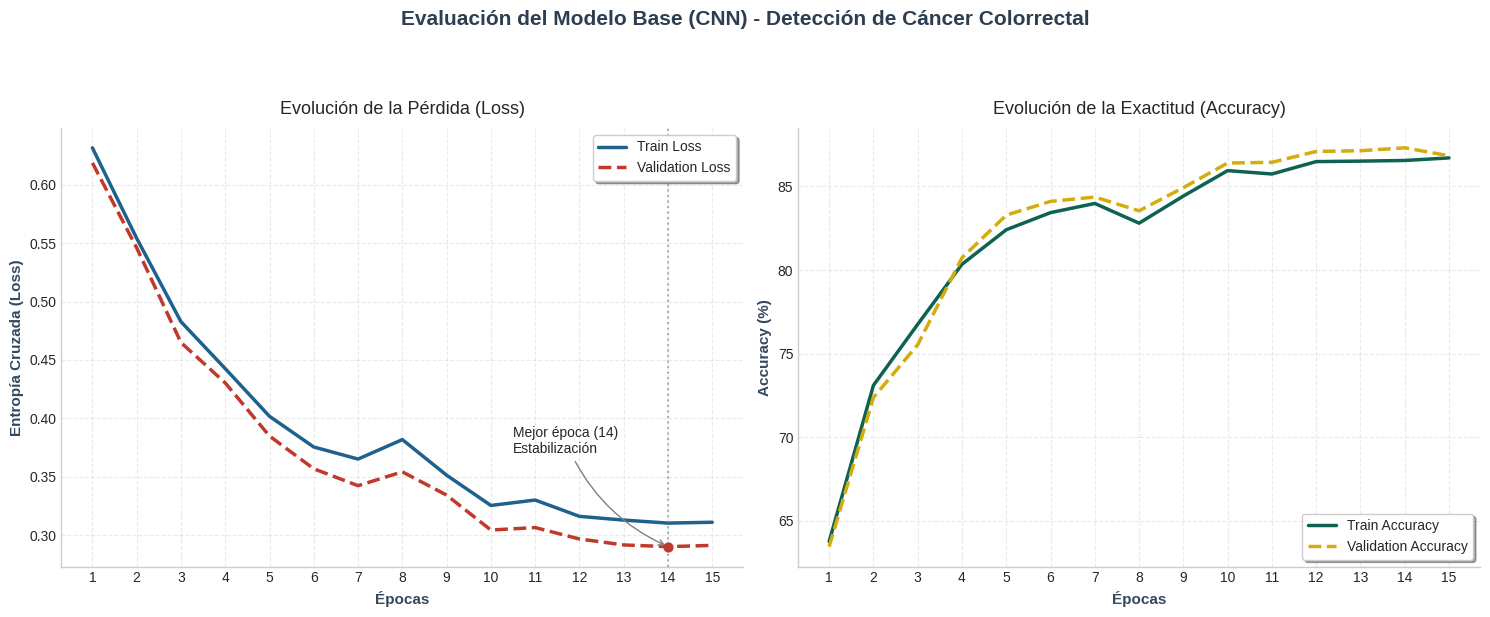

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history_scratch["train_loss"]) + 1)
n_epochs = len(history_scratch["train_loss"])

train_acc_pct = [a * 100 for a in history_scratch["train_acc"]]
val_acc_pct = [a * 100 for a in history_scratch["val_acc"]]

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')

fig.suptitle("Evaluación del Modelo Base (CNN) - Detección de Cáncer Colorrectal",
             fontsize=15, fontweight="bold", y=1.02, color="#2C3E50")

# --- Gráfica 1: Loss ---
axes[0].plot(epochs_range, history_scratch["train_loss"], label="Train Loss", color="#1F618D", linewidth=2.5)
axes[0].plot(epochs_range, history_scratch["val_loss"], label="Validation Loss", color="#C0392B", linewidth=2.5, linestyle="--")

min_val_loss = min(history_scratch["val_loss"])
best_epoch = history_scratch["val_loss"].index(min_val_loss) + 1

# Si la mejor época está cerca del inicio, el texto va a la derecha en vez de a la izquierda
offset_x = 3.5 if best_epoch > n_epochs / 2 else -1.5
text_x = best_epoch - offset_x

axes[0].axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6)
axes[0].scatter(best_epoch, min_val_loss, color='#C0392B', s=40, zorder=5)
axes[0].annotate(f'Mejor época ({best_epoch})\nEstabilización',
                 xy=(best_epoch, min_val_loss),
                 xytext=(text_x, min_val_loss + 0.08),
                 fontsize=10,
                 arrowprops=dict(arrowstyle="->", color='gray', connectionstyle="arc3,rad=.2"))

axes[0].set_title("Evolución de la Pérdida (Loss)", fontsize=13, pad=10)
axes[0].set_xlabel("Épocas", fontsize=11, fontweight="bold", color="#34495E")
axes[0].set_ylabel("Entropía Cruzada (Loss)", fontsize=11, fontweight="bold", color="#34495E")
axes[0].set_xticks(epochs_range)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend(loc="upper right", frameon=True, shadow=True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Gráfica 2: Accuracy ---
axes[1].plot(epochs_range, train_acc_pct, label="Train Accuracy", color="#0E6251", linewidth=2.5)
axes[1].plot(epochs_range, val_acc_pct, label="Validation Accuracy", color="#D4AC0D", linewidth=2.5, linestyle="--")

axes[1].set_title("Evolución de la Exactitud (Accuracy)", fontsize=13, pad=10)
axes[1].set_xlabel("Épocas", fontsize=11, fontweight="bold", color="#34495E")
axes[1].set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold", color="#34495E")
axes[1].set_xticks(epochs_range)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend(loc="lower right", frameon=True, shadow=True)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio arriba para el suptitle
plt.show()

5.4. Evaluación final en test
La evaluación debe reportarse en un conjunto no visto (test) para estimar generalización.

In [13]:
# ============ 5.4. Evaluación final en test ============
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, target_names=["Sano (Normal)", "Tumor"]))

cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.8318
Test ROC-AUC:  0.9344

               precision    recall  f1-score   support

Sano (Normal)     0.7072    0.9420    0.8079       741
        Tumor     0.9564    0.7656    0.8505      1233

     accuracy                         0.8318      1974
    macro avg     0.8318    0.8538    0.8292      1974
 weighted avg     0.8629    0.8318    0.8345      1974



array([[698,  43],
       [289, 944]])

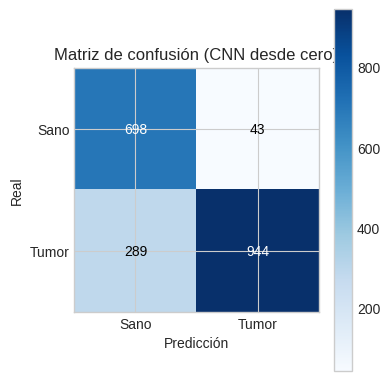

In [14]:
# ============ Matriz de confusión ============
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], ["Sano", "Tumor"])
plt.yticks([0, 1], ["Sano", "Tumor"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar()
plt.tight_layout()
plt.show()

6. Data Augmentation (aumento de datos)
En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:

Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.
Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.




In [15]:
# ============ SECCIÓN 6: DATA AUGMENTATION ============
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),                    # rotaciones pequeñas
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # traslaciones suaves
    T.ToTensor()
])
# Nota: no usamos flips horizontales/verticales -- en tejido histológico
# una imagen volteada puede alterar orientaciones biológicamente relevantes.

full_train_aug = DataClass(split="train", transform=transform_aug, download=True)
train_dataset_aug = BinaryPathMNIST(full_train_aug, CLASS_A, CLASS_B)

train_loader_aug = DataLoader(
    train_dataset_aug, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=True
)

print(f"Entrenamiento con augmentation: {len(train_dataset_aug)} imágenes")
# val_loader y test_loader se reutilizan tal cual (sin augmentation)

Entrenamiento con augmentation: 20771 imágenes


In [16]:
# ============ Entrenar model_aug (mismo diseño, para comparar) ============
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_aug.parameters(), lr=5e-4, weight_decay=1e-4)

epochs = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

history_aug = {
    "train_loss": [], "val_loss": [],
    "train_acc": [],  "val_acc": [],
    "diff_loss": [],  "diff_acc": []
}

print(f"{'Época':^7} | {'Train Loss':^10} | {'Val Loss':^10} | {'Dif Loss':^10} | {'Train Acc':^10} | {'Val Acc':^10} | {'Dif Acc':^10}")
print("-" * 85)

for epoch in range(1, epochs + 1):
    model_aug.train()
    for x, y in train_loader_aug:
        x, y = x.to(device), y.to(device).long().view(-1)
        optimizer.zero_grad()
        loss = criterion(model_aug(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_aug.parameters(), max_norm=0.5)
        optimizer.step()

    scheduler.step()

    tr_l = compute_loss(model_aug, train_loader_aug)
    va_l = compute_loss(model_aug, val_loader)
    tr_a, _, _, _, _ = evaluate(model_aug, train_loader_aug)
    va_a, va_auc, _, _, _ = evaluate(model_aug, val_loader)

    diff_l = abs(va_l - tr_l)
    diff_a = abs(tr_a - va_a)

    history_aug["train_loss"].append(tr_l)
    history_aug["val_loss"].append(va_l)
    history_aug["train_acc"].append(tr_a)
    history_aug["val_acc"].append(va_a)
    history_aug["diff_loss"].append(diff_l)
    history_aug["diff_acc"].append(diff_a)

    print(f" {epoch:02d}/{epochs}  |  {tr_l:8.4f}  |  {va_l:8.4f}  |  {diff_l:8.4f}  |  {tr_a:8.4f}  |  {va_a:8.4f}  |  {diff_a:8.4f}")

 Época  | Train Loss |  Val Loss  |  Dif Loss  | Train Acc  |  Val Acc   |  Dif Acc  
-------------------------------------------------------------------------------------
 01/15  |    0.5880  |    0.5838  |    0.0041  |    0.7338  |    0.7311  |    0.0027
 02/15  |    0.4628  |    0.4488  |    0.0140  |    0.7923  |    0.7973  |    0.0050
 03/15  |    0.4047  |    0.3904  |    0.0144  |    0.8188  |    0.8259  |    0.0071
 04/15  |    0.3553  |    0.3461  |    0.0092  |    0.8497  |    0.8484  |    0.0013
 05/15  |    0.3604  |    0.3502  |    0.0103  |    0.8413  |    0.8393  |    0.0020
 06/15  |    0.3253  |    0.3192  |    0.0061  |    0.8594  |    0.8588  |    0.0006
 07/15  |    0.3116  |    0.3096  |    0.0020  |    0.8668  |    0.8649  |    0.0020
 08/15  |    0.3049  |    0.2993  |    0.0057  |    0.8734  |    0.8783  |    0.0049
 09/15  |    0.2870  |    0.2814  |    0.0056  |    0.8831  |    0.8800  |    0.0031
 10/15  |    0.2837  |    0.2810  |    0.0027  |    0.8811  |  

6.1. Comparación rápida

In [17]:
# ============ 6.1. Comparación rápida ============
test_acc_aug, test_auc_aug, y_true_aug, y_pred_aug, y_prob_aug = evaluate(model_aug, test_loader)

print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8318 | auc=0.9344
CNN desde cero (con aug)  | acc=0.8941 | auc=0.9506


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [18]:
# ============ 7. TRANSFER LEARNING: transforms y datasets ============
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),                       # tamaño típico de entrada para ResNet
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
    # Nota: no hace falta repeat(3,1,1) -> PathMNIST ya es RGB (tinción H&E a color)
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

full_train_tl = DataClass(split="train", transform=transform_tl_train, download=True)
full_val_tl   = DataClass(split="val",   transform=transform_tl_eval,  download=True)
full_test_tl  = DataClass(split="test",  transform=transform_tl_eval,  download=True)

train_dataset_tl = BinaryPathMNIST(full_train_tl, CLASS_A, CLASS_B)
val_dataset_tl   = BinaryPathMNIST(full_val_tl,   CLASS_A, CLASS_B)
test_dataset_tl  = BinaryPathMNIST(full_test_tl,  CLASS_A, CLASS_B)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl  = DataLoader(test_dataset_tl,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape  # debería salir [64, 3, 224, 224]

torch.Size([64, 3, 224, 224])

7.1. Construir el modelo preentrenado (ResNet18)

In [19]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)  # num_classes = 2 (Sano/Tumor)
resnet = resnet.to(device)

# Congelamos todo el backbone al inicio
for name, param in resnet.named_parameters():
    param.requires_grad = False

# Solo entrenamos la última capa (el clasificador nuevo)
for param in resnet.fc.parameters():
    param.requires_grad = True


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Entrenamiento etapa 1 (solo la capa final)

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    resnet.train()
    losses = []
    for x, y in train_loader_tl:
        x, y = x.to(device), y.to(device).long().view(-1)
        optimizer.zero_grad()
        logits = resnet(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.3487 | val_acc=0.9095 | val_auc=0.9658
Stage1 Epoch 02 | train_loss=0.2609 | val_acc=0.9177 | val_auc=0.9725
Stage1 Epoch 03 | train_loss=0.2489 | val_acc=0.9121 | val_auc=0.9736
Stage1 Epoch 04 | train_loss=0.2363 | val_acc=0.9030 | val_auc=0.9745


7.2. Fine-tuning (descongelar capas)

In [21]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)

17

In [22]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)  # LR más bajo: ya no partimos de cero

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    resnet.train()
    losses = []
    for x, y in train_loader_tl:
        x, y = x.to(device), y.to(device).long().view(-1)
        optimizer.zero_grad()
        logits = resnet(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.1356 | val_acc=0.9792 | val_auc=0.9979
Stage2 Epoch 02 | train_loss=0.0767 | val_acc=0.9706 | val_auc=0.9984
Stage2 Epoch 03 | train_loss=0.0536 | val_acc=0.9801 | val_auc=0.9990
Stage2 Epoch 04 | train_loss=0.0391 | val_acc=0.9857 | val_auc=0.9993


7.3. Evaluación en test del modelo con transfer learning

In [23]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4, target_names=["Sano (Normal)", "Tumor"]))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.9666 | test_auc=0.9940

               precision    recall  f1-score   support

Sano (Normal)     0.9435    0.9690    0.9561       741
        Tumor     0.9810    0.9651    0.9730      1233

     accuracy                         0.9666      1974
    macro avg     0.9623    0.9670    0.9645      1974
 weighted avg     0.9669    0.9666    0.9667      1974



array([[ 718,   23],
       [  43, 1190]])

7.4. Comparación global (resumen)

In [24]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f}     | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f}  | auc={test_auc_tl:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug)   | acc=0.8318     | auc=0.9344
CNN desde cero (con aug)   | acc=0.8941 | auc=0.9506
Transfer learning (ResNet) | acc=0.9666  | auc=0.9940


8. Interpretabilidad básica: Grad-CAM

In [25]:
# ============ 8. GRAD-CAM ============
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


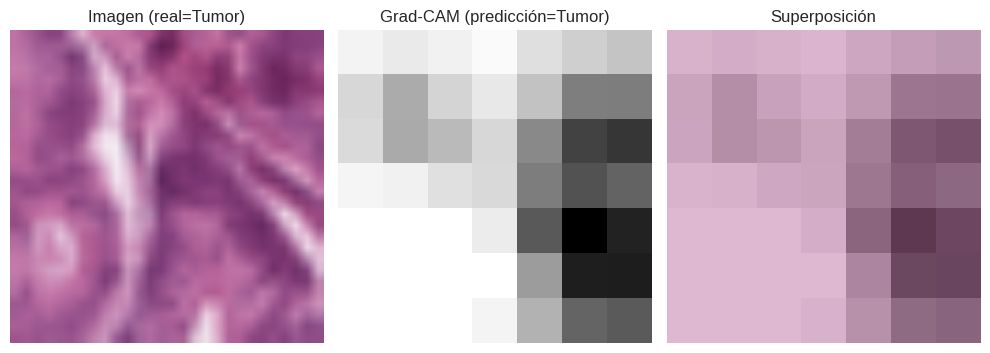

In [26]:
# ============ Visualización Grad-CAM ============
LABELS = {0: "Sano", 1: "Tumor"}

idx = 0  # cambia este índice para ver otras imágenes del test
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x.permute(1, 2, 0).numpy()  # RGB: [C,H,W] -> [H,W,C] (PathMNIST no necesita cmap="gray")

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (real={LABELS[int(y.item())]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (predicción={LABELS[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

Sección 10 — código para guardar los 3 modelos entrenados:

In [27]:
# ============ 10. Guardar y cargar modelos ============
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

In [28]:
from google.colab import files

files.download("models/cnn_scratch.pth")
files.download("models/cnn_aug.pth")
files.download("models/resnet_transfer.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Conclusión final

Este trabajo replicó el flujo de un notebook de referencia sobre CNN aplicadas a imágenes médicas,
adaptándolo a un problema propio: la clasificación binaria de **tejido sano vs. tejido tumoral**
(colorectal adenocarcinoma epithelium) a partir de imágenes histológicas del dataset PathMNIST
(subconjunto de 2 de sus 9 clases: "normal colon mucosa" y "colorectal adenocarcinoma epithelium"),
con un total de 25,054 imágenes (20,771 entrenamiento / 2,309 validación / 1,974 prueba).

**Resultados obtenidos en test:**

| Modelo                       | Test Accuracy | Test ROC-AUC | Recall Tumor |
|-------------------------------|:---:|:---:|:---:|
| CNN desde cero (sin aug)      | 0.8318 | 0.9344 | 0.7656 |
| CNN desde cero (con aug)      | 0.8941 | 0.9506 | — |
| Transfer Learning (ResNet18)  | 0.9666 | 0.9940 | 0.9651 |

**Hallazgos principales:**

1. El modelo base (CNN entrenada desde cero) alcanzó un ROC-AUC de 0.9344, con buena separación
   entre clases a nivel de probabilidades. Sin embargo, con el umbral por defecto (0.5) el recall
   de la clase Tumor fue de 76.56%: de 1,233 casos con tumor real, 289 se clasificaron erróneamente
   como sanos (falsos negativos) — el tipo de error más costoso en un contexto de detección médica.

2. El aumento de datos (rotaciones pequeñas y traslaciones suaves) sí mejoró el desempeño en este
   caso: accuracy subió de 0.8318 a 0.8941 y ROC-AUC de 0.9344 a 0.9506. Esto sugiere que la
   variabilidad adicional introducida por el augmentation ayudó al modelo a generalizar mejor sobre
   el conjunto de prueba, sin perjudicar la convergencia (gracias también al learning rate scheduler
   aplicado durante el entrenamiento).

3. El transfer learning con ResNet18 preentrenada fue, por amplio margen, el mejor modelo:
   accuracy de 0.9666 y ROC-AUC de 0.9940. El recall de Tumor subió de 76.56% (modelo base) a 96.51%,
   y el de Sano se mantuvo alto (96.90%). Esto confirma la ventaja esperada del transfer learning:
   aprovechar representaciones visuales ya aprendidas en ImageNet aceleró la convergencia (en solo
   4+4 épocas superó ampliamente a la CNN entrenada desde cero durante 15 épocas) y mejoró
   sustancialmente la capacidad de generalización, incluso tratándose de un dominio (histología)
   muy distinto al de las fotografías naturales de ImageNet.

**Limitaciones:**

- El dataset, aunque considerablemente más grande que el original (BR35H, 3,000 imágenes), sigue
  siendo un subconjunto filtrado de solo 2 de las 9 clases de PathMNIST, no un dataset diseñado
  específicamente para esta tarea binaria.
- El umbral de decisión (0.5) no fue optimizado; ajustarlo podría mejorar aún más el recall de
  Tumor en el modelo base, a costa de más falsos positivos en Sano.
- Grad-CAM ofrece una visualización útil de las regiones que influyen en la predicción, pero no
  constituye una validación médica ni reemplaza el criterio de un patólogo.

**Conclusión general:**

El ejercicio demuestra el flujo completo de un proyecto de clasificación de imágenes médicas:
desde la preparación de datos y una CNN base, pasando por aumento de datos y transfer learning,
hasta la interpretabilidad del modelo. Los tres modelos mejoraron progresivamente (CNN base →
CNN con augmentation → transfer learning), confirmando que tanto el aumento de datos como,
sobre todo, el aprovechamiento de un modelo preentrenado son estrategias efectivas frente a
entrenar una arquitectura desde cero, especialmente considerando que el accuracy global no es
suficiente para evaluar modelos médicos: el recall de la clase positiva y el ROC-AUC son
los que realmente informan si un modelo es clínicamente útil.